## 心瓣偵測的練習題
- 2025-10-03?
 - 完成套件安裝與路徑設定
 - 完成baseline訓練

##### 評分方式
- 模型需預測類別、信心分數、預測框左上角和右下角xy座標等目標，使用AP@0.5（即 IoU ≥ 0.5 時的 Average Precision）分數評估模型效能：

In [1]:
# 設定nb頁面佔滿瀏覽器寬度
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>")) # ex: width:1200px

#### 1.設置環境

從畫面右上角確認有使用到GPU

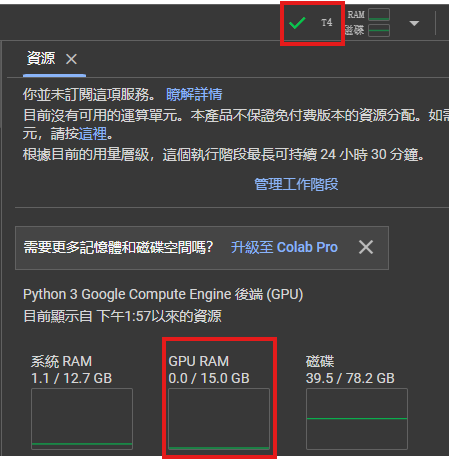

如果沒連到的話請切換到GPU

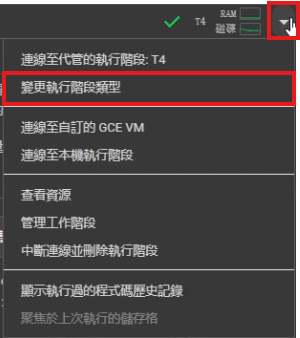
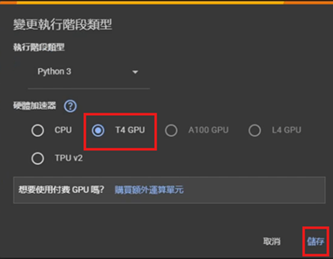

Colab區塊左方有綠色勾代表執行完成且成功 image.png


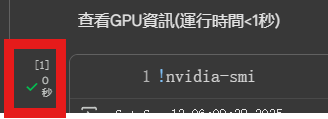

區塊左方有圈在轉代表執行中 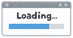

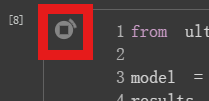

區塊左方有紅色驚嘆號代表運行錯誤 image.png

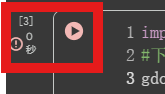

查看GPU資訊(運行時間<1秒) image.png

In [1]:
!nvidia-smi

Thu Oct  2 16:56:09 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.08             Driver Version: 535.161.08   CUDA Version: 12.4     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-SXM2-32GB           On  | 00000000:DB:00.0 Off |                    0 |
| N/A   28C    P0              42W / 300W |      0MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

確保不會出現編碼錯誤(運行時間<1秒) image.png

In [2]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

下載YOLOv12套件(運行時間12秒) image.png

In [3]:
# !pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.166 🚀 Python-3.10.12 torch-2.7.0+cu126 CUDA:0 (Tesla V100-SXM2-32GB, 32501MiB)
Setup complete ✅ (36 CPUs, 754.3 GB RAM, 0.8/100.0 GB disk)


#### 2. 上傳資料集和 .yaml 檔

.yaml 檔內容

.yaml 範例:https://drive.google.com/file/d/13hSr3sa2wOZqlvY1RAwr2msCfTdkfjMe/view?usp=sharing

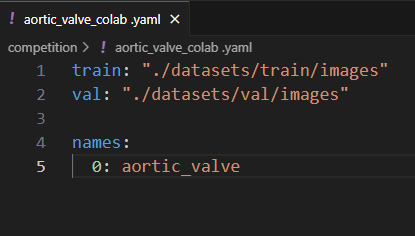



上傳資料集


將training_image.zip、training_label.zip和aortic_valve_colab.yaml上傳至個人的Google雲端硬碟


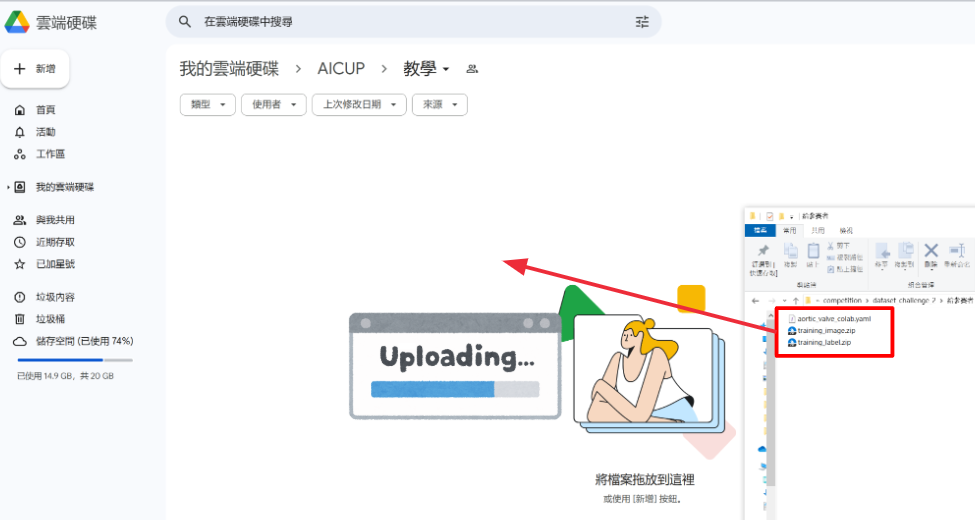

更改檔案權限(training_image.zip、training_label.zip和aortic_valve_colab.yaml**三個檔案權限都要更改**) image.png

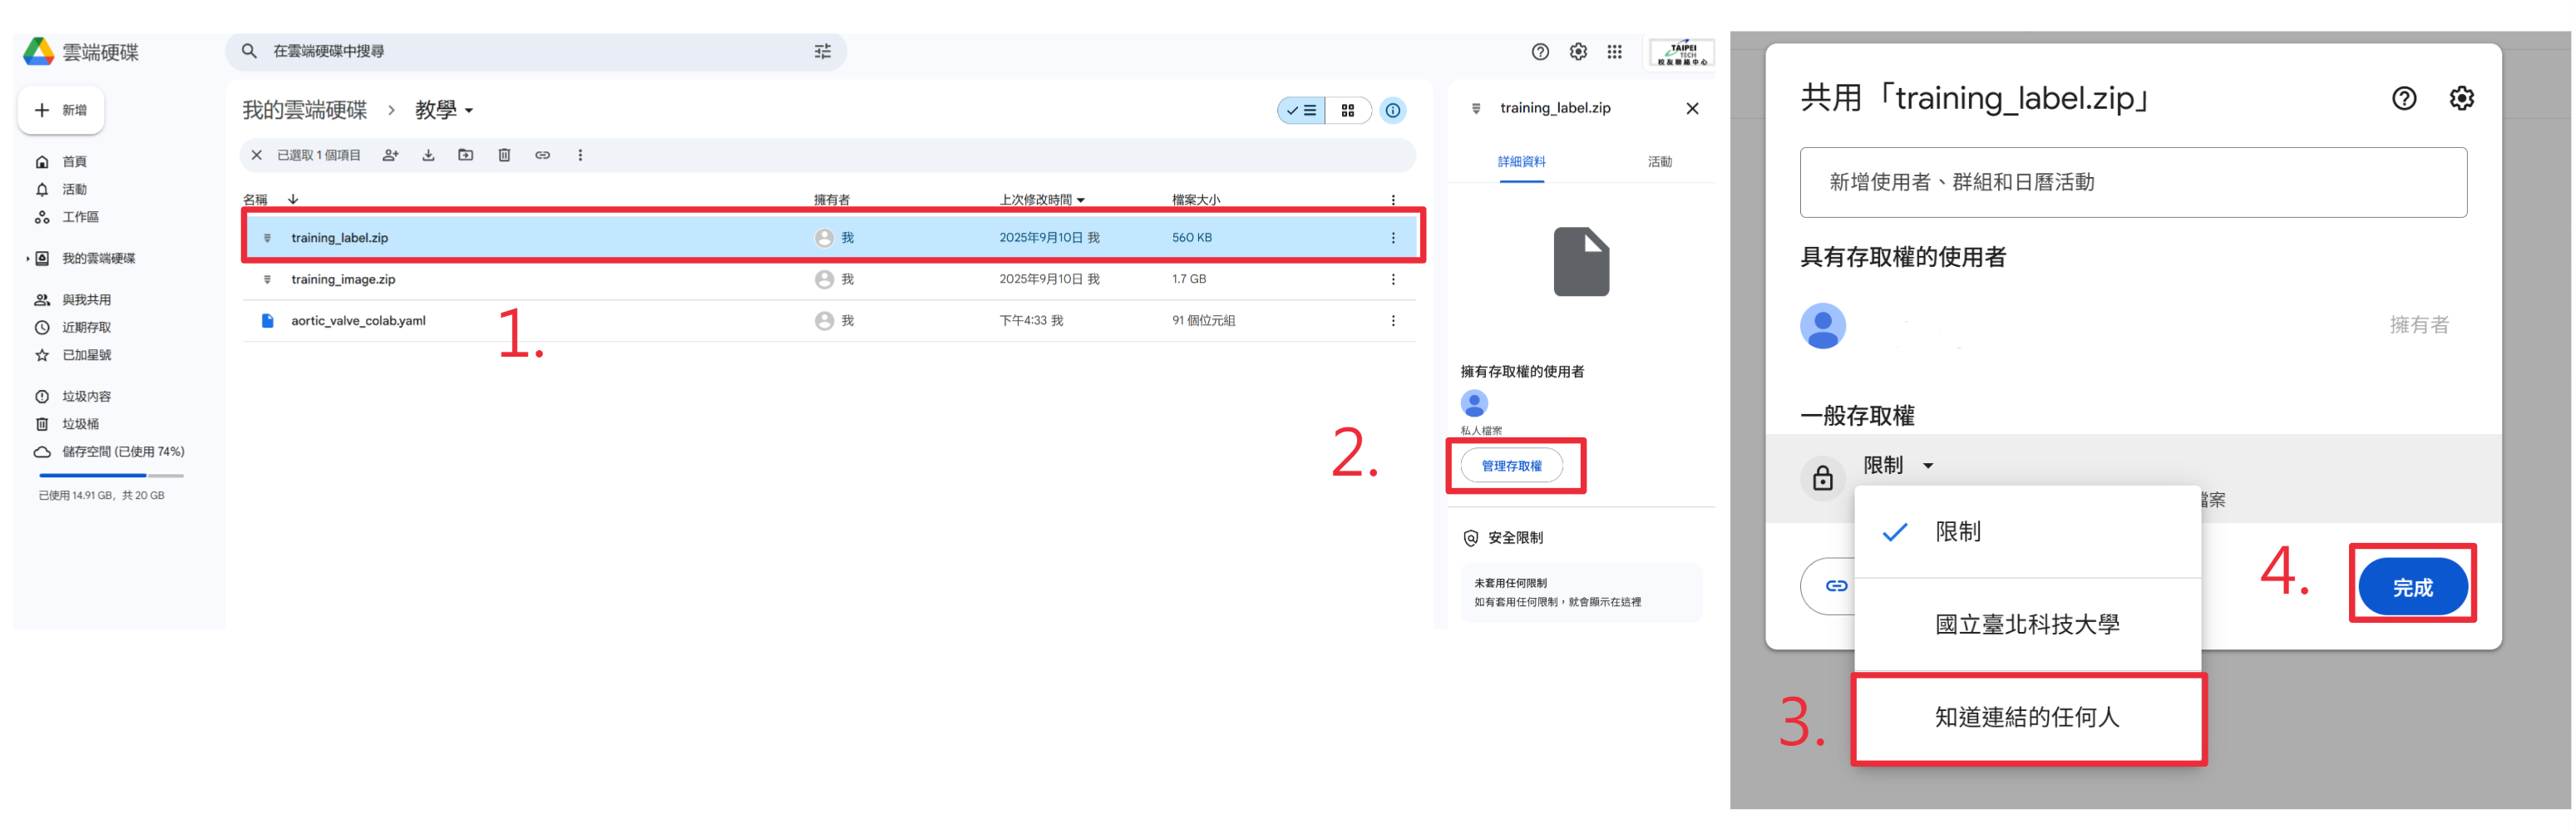

取得雲端資料下載連結(下方程式需要用到)
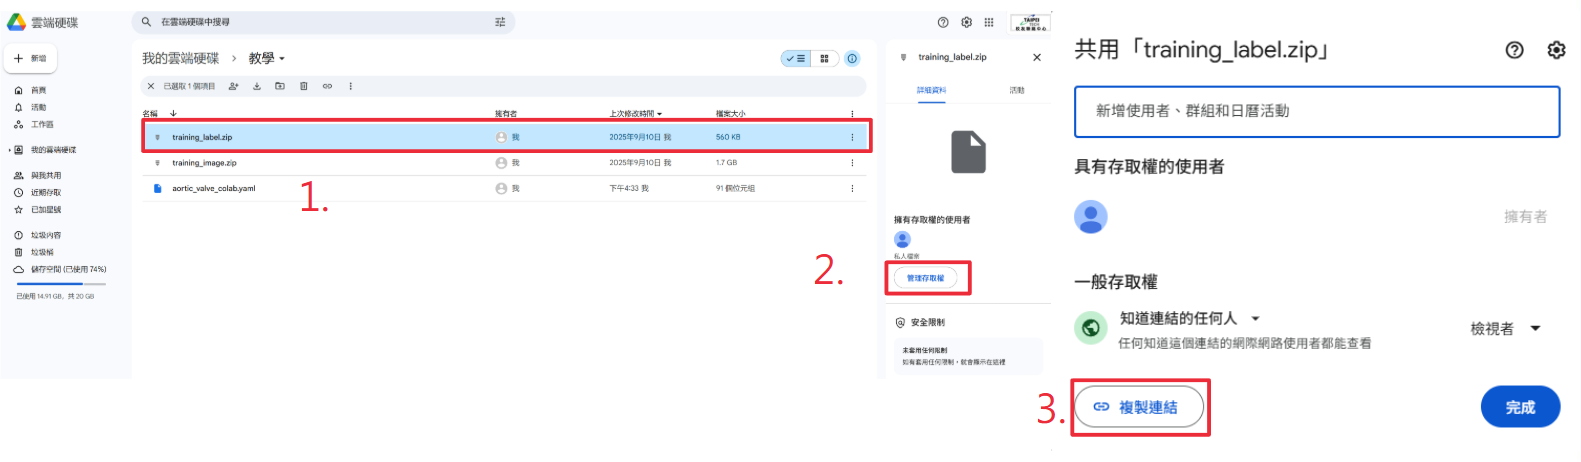

將剛剛取得的網址透過下方網址轉換成直接下載的格式


https://sites.google.com/view/twdrivefromdownload/%E7%B9%81%E9%AB%94%E4%B8%AD%E6%96%87traditional-chinese?authuser=0

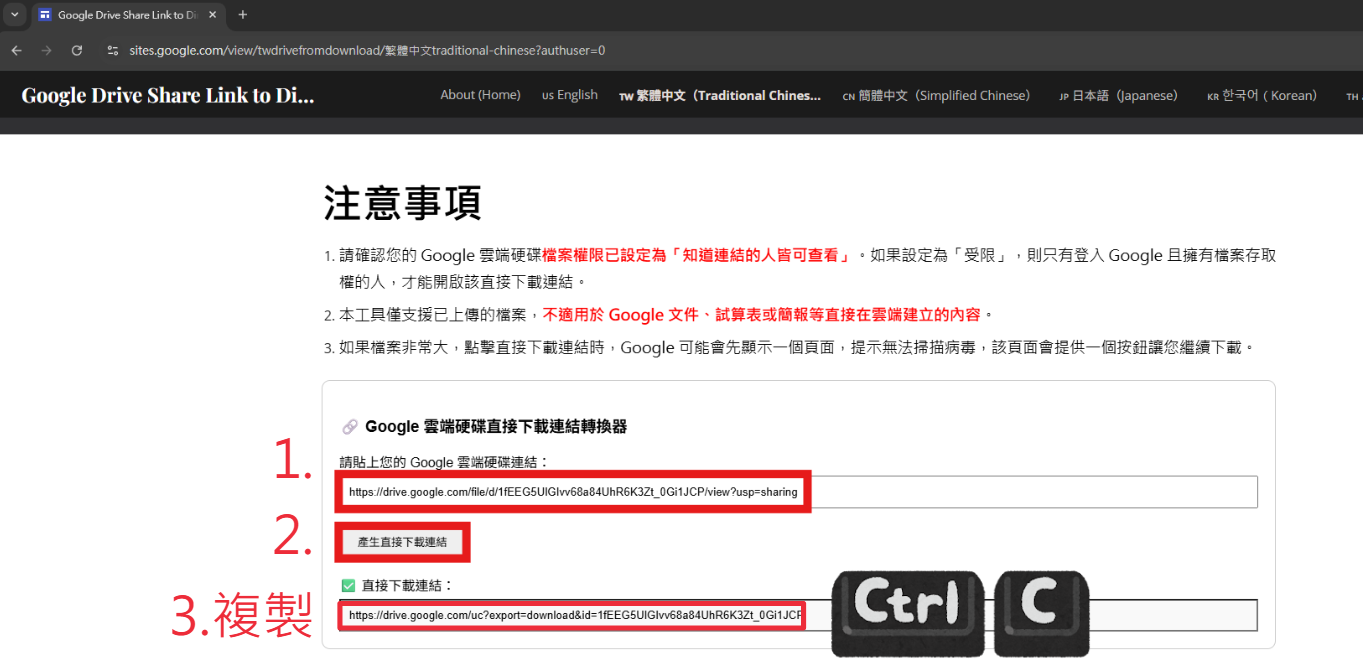

透過上面方法更改下方程式的三個網址(執行時間<1分鐘) image.png


 *請自行上傳雲端替換成自己的連結，此範例連結雖然與最初競賽資料集相同，但不保證會更新且隨時有可能會刪除!!!

In [ ]:
#下載資料集
import gdown
import os
import shutil

#下載training_image.zip
gdown.download("https://drive.google.com/uc?export=download&id=1FfrsOgeJKSHtRM3Q649HJvSF1l4blxpl","/content/training_image.zip")
#下載training_label.zip
gdown.download("https://drive.google.com/uc?export=download&id=1KmYS2JhAexpWWlzlo_qwoX1TifA1COWW","/content/training_label.zip")
#下載訓練aortic_valve_colab.yaml
gdown.download("https://drive.google.com/u/0/uc?id=1OyGJ7mfVLutjkE55U9wfs4bmHCtIN1cv&export=download","/content/aortic_valve_colab.yaml")

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1FfrsOgeJKSHtRM3Q649HJvSF1l4blxpl
From (redirected): https://drive.google.com/uc?export=download&id=1FfrsOgeJKSHtRM3Q649HJvSF1l4blxpl&confirm=t&uuid=e783eb76-cf7f-45d5-bcaf-07c2e768779f
To: /content/training_image.zip
100%|██████████| 1.83G/1.83G [00:18<00:00, 101MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1KmYS2JhAexpWWlzlo_qwoX1TifA1COWW
To: /content/training_label.zip
100%|██████████| 573k/573k [00:00<00:00, 114MB/s]
Downloading...
From: https://drive.google.com/u/0/uc?id=1OyGJ7mfVLutjkE55U9wfs4bmHCtIN1cv&export=download
To: /content/aortic_valve_colab.yaml
100%|██████████| 91.0/91.0 [00:00<00:00, 454kB/s]


'/content/aortic_valve_colab.yaml'

移動檔案(透過下方程式，執行時間<1分鐘)


此範例將前30筆資料用於訓練，後20筆資料用於驗證，參賽者可在程式中53行及56行更改比例

因為Colab運算資源有限此處只採用有標註檔的圖片，其餘圖片也可以自行修改程式利用

將前30筆資料的圖片全部移動至./datasets/train/images，


 前30筆資料的標註全部移動至./datasets/train/labels，


 後20筆資料的圖片全部移動至./datasets/val/images，


 後20筆資料的標註全部移動至./datasets/val/labels。


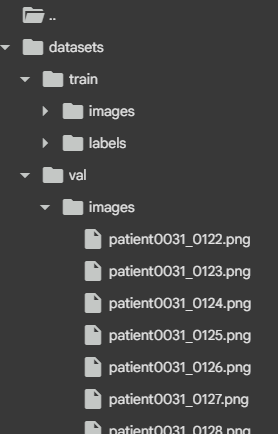

In [1]:
import os
import shutil

In [3]:
#移動檔案
def find_patient_root(root):
    """往下找，直到找到含有 patientXXXX 的資料夾"""
    for dirpath, dirnames, filenames in os.walk(root):
        if any(d.startswith("patient") for d in dirnames):
            return dirpath
    return root  # fallback

# 解壓縮到固定資料夾
if not os.path.isdir("./training_image") and os.path.exists("training_image.zip"):
    os.makedirs("./training_image", exist_ok=True)
    !unzip -q training_image.zip -d ./training_image

if not os.path.isdir("./training_label") and os.path.exists("training_label.zip"):
    os.makedirs("./training_label", exist_ok=True)
    !unzip -q training_label.zip -d ./training_label

IMG_ROOT = find_patient_root("./training_image")
LBL_ROOT = find_patient_root("./training_label")

print("IMG_ROOT =", IMG_ROOT)
print("LBL_ROOT =", LBL_ROOT)

# 建立輸出資料夾
os.makedirs("./datasets/train/images", exist_ok=True)
os.makedirs("./datasets/train/labels", exist_ok=True)
os.makedirs("./datasets/val/images", exist_ok=True)
os.makedirs("./datasets/val/labels", exist_ok=True)

def move_patients(start, end, split):
    for i in range(start, end + 1):
        patient = f"patient{i:04d}"
        img_dir = os.path.join(IMG_ROOT, patient)
        lbl_dir = os.path.join(LBL_ROOT, patient)
        if not os.path.isdir(lbl_dir):
            continue

        for fname in os.listdir(lbl_dir):
            if not fname.endswith(".txt"):  # 只有有標記檔的圖會被複製到dataset中 （需要補空txt！！）
                continue

            label_path = os.path.join(lbl_dir, fname)
            base, _ = os.path.splitext(fname)  # 取出檔名不含副檔名
            img_path = os.path.join(img_dir, base + ".png")
            if not os.path.exists(img_path):
                print(f"找不到對應圖片: {img_path}")
                continue

            shutil.move(img_path, f"./datasets/{split}/images/")
            shutil.move(label_path, f"./datasets/{split}/labels/")

# # patient0001~0030 → train
# move_patients(1, 30, "train")

# # patient0031~0050 → val
# move_patients(31, 50, "val")

# print("完成移動！")

IMG_ROOT = ./training_image
LBL_ROOT = ./training_label


### ATE_ train/val 補空txt

In [2]:
# 補上所有空的txt檔案 

IMG_ROOT = find_patient_root("./training_image")
LBL_ROOT = find_patient_root("./training_label")

print("IMG_ROOT =", IMG_ROOT)
print("LBL_ROOT =", LBL_ROOT)


        
            
def cp_patients(start, end, split):
    """
    複製病患資料，如果標註檔缺失則建立一個空 txt 檔並計數。
    
    Args:
        start (int): 起始病患編號
        end (int): 結束病患編號
        split (str): 目的地資料夾名稱 (e.g., 'train', 'val')
        IMG_ROOT (str): 原始圖片根目錄
        LBL_ROOT (str): 原始標註檔根目錄

    Returns:
        int: 建立的空標註檔 (.txt) 總數。
    """
    # 初始化計數器
    empty_label_count = 0
    
    # 確保目的地路徑存在
    os.makedirs(f"./datasets/{split}/images/", exist_ok=True)
    os.makedirs(f"./datasets/{split}/labels/", exist_ok=True)

    for i in range(start, end + 1):
        patient = f"patient{i:04d}"
        img_dir = os.path.join(IMG_ROOT, patient)
        lbl_dir = os.path.join(LBL_ROOT, patient)
        
        # 檢查標註檔根目錄是否存在
        if not os.path.isdir(lbl_dir):
            continue

        # 檢查原始圖片目錄是否存在且有檔案
        if not os.path.isdir(img_dir):
            continue
            
        for fname in os.listdir(img_dir):
            if not fname.endswith(".png"):
                continue

            image_path = os.path.join(img_dir, fname)
            base, _ = os.path.splitext(fname)
            
            # 定義目標標註檔的路徑 (原始路徑)
            label_path = os.path.join(lbl_dir, base + ".txt")
            
            # 定義目標複製路徑 (新的路徑)
            dest_label_path = os.path.join(f"./datasets/{split}/labels/", base + ".txt")

            # --- 【判斷標註檔缺失與補空檔邏輯】 ---
            if not os.path.exists(label_path):
                print(f"警告: 找不到標註檔 -> {label_path}")
                
                # 1. 建立一個空的 txt 檔案到目的地資料夾中
                try:
                    with open(dest_label_path, 'w') as f:
                        f.write("") # 寫入空字串
                    print(f"已在目的地補上空 txt 檔: {dest_label_path}")
                    
                    # 遞增計數器
                    empty_label_count += 1
                    
                except Exception as e:
                    print(f"寫入空檔案時發生錯誤: {e}")
                    continue # 如果寫入失敗，則跳過此張圖片

            else:
                # 2. 如果標註檔存在，則複製標註檔到目的地
                try:
                    shutil.copy(label_path, dest_label_path)
                except Exception as e:
                    print(f"複製標註檔失敗: {e}")
                    continue
            
            # 3. 複製圖片
            try:
                # 確保複製時使用完整的檔名
                shutil.copy(image_path, f"./datasets/{split}/images/{fname}")
            except Exception as e:
                print(f"複製圖片檔失敗: {e}")
                
    print(f"補充了{split}共{empty_label_count}個空txt檔！")




# patient0001~0040 → train 80%
cp_patients(1, 40, "train")

# patient0041~0050 → val 20%
cp_patients(41, 50, "val")

print("完成複製！")

IMG_ROOT = ./training_image
LBL_ROOT = ./training_label
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0010.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0010.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0020.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0020.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0308.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0308.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0156.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0156.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0067.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0067.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0341.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0341.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0031.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0031.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0101.txt
已在目的地

警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0102.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0102.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0304.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0304.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0058.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0058.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0199.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0199.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0177.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0177.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0081.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0081.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0064.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0064.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0093.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0093.txt


警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0116.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0116.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0110.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0110.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0190.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0190.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0189.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0189.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0332.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0332.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0303.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0303.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0089.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0089.txt
警告: 找不到標註檔 -> ./training_label/patient0001/patient0001_0174.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0001_0174.txt


警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0049.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0049.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0296.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0296.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0098.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0098.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0045.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0045.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0336.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0336.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0171.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0171.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0358.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0358.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0006.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0006.txt


警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0188.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0188.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0314.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0314.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0180.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0180.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0323.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0323.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0116.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0116.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0038.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0038.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0135.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0135.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0309.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0309.txt


警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0008.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0008.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0144.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0144.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0054.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0054.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0166.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0166.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0198.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0198.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0270.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0270.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0090.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0090.txt
警告: 找不到標註檔 -> ./training_label/patient0002/patient0002_0285.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0002_0285.txt


警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0112.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0112.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0322.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0322.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0093.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0093.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0116.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0116.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0307.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0307.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0170.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0170.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0166.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0166.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0045.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0045.txt


警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0105.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0105.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0023.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0023.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0134.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0134.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0039.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0039.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0042.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0042.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0118.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0118.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0178.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0178.txt
警告: 找不到標註檔 -> ./training_label/patient0003/patient0003_0175.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0003_0175.txt


警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0183.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0183.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0086.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0086.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0058.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0058.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0020.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0020.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0295.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0295.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0047.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0047.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0272.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0272.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0123.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0123.txt


已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0092.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0313.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0313.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0010.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0010.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0146.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0146.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0125.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0125.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0117.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0117.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0163.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0163.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0290.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0290.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0292.txt


已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0137.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0024.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0024.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0315.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0315.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0021.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0021.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0063.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0063.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0276.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0276.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0134.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0134.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0308.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0004_0308.txt
警告: 找不到標註檔 -> ./training_label/patient0004/patient0004_0314.txt


警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0195.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0195.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0098.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0098.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0032.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0032.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0268.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0268.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0119.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0119.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0277.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0277.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0285.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0285.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0030.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0030.txt


警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0279.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0279.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0202.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0202.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0020.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0020.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0123.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0123.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0016.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0016.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0064.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0064.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0005.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0005.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0278.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0278.txt


警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0265.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0265.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0103.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0103.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0232.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0232.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0218.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0218.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0100.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0100.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0282.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0282.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0004.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0004.txt
警告: 找不到標註檔 -> ./training_label/patient0005/patient0005_0025.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0005_0025.txt


已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0100.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0269.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0269.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0249.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0249.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0125.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0125.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0007.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0007.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0271.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0271.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0098.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0098.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0242.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0242.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0072.txt


警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0070.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0070.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0200.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0200.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0029.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0029.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0042.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0042.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0275.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0275.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0128.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0128.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0142.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0142.txt
警告: 找不到標註檔 -> ./training_label/patient0006/patient0006_0094.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0006_0094.txt


警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0300.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0300.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0116.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0116.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0063.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0063.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0384.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0384.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0120.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0120.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0311.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0311.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0364.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0364.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0206.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0206.txt


警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0343.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0343.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0372.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0372.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0111.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0111.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0337.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0337.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0282.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0282.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0383.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0383.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0172.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0172.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0167.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0167.txt


警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0305.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0305.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0060.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0060.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0092.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0092.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0332.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0332.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0189.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0189.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0133.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0133.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0165.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0165.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0180.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0180.txt


警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0283.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0283.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0147.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0147.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0195.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0195.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0106.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0106.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0090.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0090.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0144.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0144.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0331.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0331.txt
警告: 找不到標註檔 -> ./training_label/patient0007/patient0007_0389.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0007_0389.txt


警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0221.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0221.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0276.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0276.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0078.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0078.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0088.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0088.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0067.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0067.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0236.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0236.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0102.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0102.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0241.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0241.txt


警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0133.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0133.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0084.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0084.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0124.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0124.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0170.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0170.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0226.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0226.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0235.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0235.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0123.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0123.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0106.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0106.txt


警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0007.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0007.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0066.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0066.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0158.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0158.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0042.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0042.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0227.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0227.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0273.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0273.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0053.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0053.txt
警告: 找不到標註檔 -> ./training_label/patient0008/patient0008_0081.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0008_0081.txt


警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0042.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0042.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0124.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0124.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0100.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0100.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0141.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0141.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0296.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0296.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0040.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0040.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0276.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0276.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0075.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0075.txt


警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0243.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0243.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0073.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0073.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0142.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0142.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0091.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0091.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0250.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0250.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0015.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0015.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0094.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0094.txt
警告: 找不到標註檔 -> ./training_label/patient0009/patient0009_0265.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0009_0265.txt


警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0100.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0100.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0269.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0269.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0045.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0045.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0032.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0032.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0217.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0217.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0129.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0129.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0274.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0274.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0054.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0054.txt


警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0001.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0001.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0094.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0094.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0117.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0117.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0049.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0049.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0222.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0222.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0108.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0108.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0224.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0224.txt
警告: 找不到標註檔 -> ./training_label/patient0010/patient0010_0091.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0010_0091.txt


警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0047.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0047.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0100.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0100.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0130.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0130.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0146.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0146.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0076.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0076.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0088.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0088.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0171.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0171.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0249.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0249.txt


警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0178.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0178.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0079.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0079.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0004.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0004.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0131.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0131.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0021.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0021.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0126.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0126.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0091.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0091.txt
警告: 找不到標註檔 -> ./training_label/patient0011/patient0011_0238.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0011_0238.txt


警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0341.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0341.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0176.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0176.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0065.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0065.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0184.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0184.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0044.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0044.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0023.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0023.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0331.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0331.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0261.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0261.txt


警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0050.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0050.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0279.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0279.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0096.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0096.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0098.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0098.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0159.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0159.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0063.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0063.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0356.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0356.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0027.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0027.txt


警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0180.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0180.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0332.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0332.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0156.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0156.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0109.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0109.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0071.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0071.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0311.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0311.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0115.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0115.txt
警告: 找不到標註檔 -> ./training_label/patient0012/patient0012_0036.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0012_0036.txt


警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0108.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0108.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0227.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0227.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0046.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0046.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0003.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0003.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0031.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0031.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0313.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0313.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0051.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0051.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0240.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0240.txt


警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0107.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0107.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0134.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0134.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0257.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0257.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0015.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0015.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0300.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0300.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0225.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0225.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0321.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0321.txt
警告: 找不到標註檔 -> ./training_label/patient0013/patient0013_0140.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0013_0140.txt


警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0269.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0269.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0110.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0110.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0085.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0085.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0235.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0235.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0144.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0144.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0229.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0229.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0277.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0277.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0102.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0102.txt


已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0256.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0224.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0224.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0275.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0275.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0069.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0069.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0018.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0018.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0051.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0051.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0236.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0236.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0233.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0233.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0083.txt


警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0106.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0106.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0041.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0041.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0126.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0126.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0105.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0105.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0219.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0219.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0138.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0138.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0036.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0036.txt
警告: 找不到標註檔 -> ./training_label/patient0014/patient0014_0090.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0014_0090.txt


警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0168.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0168.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0263.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0263.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0193.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0193.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0278.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0278.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0184.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0184.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0192.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0192.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0053.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0053.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0093.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0093.txt


警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0011.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0011.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0156.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0156.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0084.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0084.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0026.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0026.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0115.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0115.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0102.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0102.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0092.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0092.txt
警告: 找不到標註檔 -> ./training_label/patient0015/patient0015_0099.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0015_0099.txt


警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0099.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0099.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0378.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0378.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0222.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0222.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0316.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0316.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0356.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0356.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0335.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0335.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0011.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0011.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0405.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0405.txt


警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0197.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0197.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0029.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0029.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0006.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0006.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0312.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0312.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0085.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0085.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0332.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0332.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0353.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0353.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0357.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0357.txt


警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0362.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0362.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0207.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0207.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0318.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0318.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0101.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0101.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0420.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0420.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0104.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0104.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0359.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0359.txt
警告: 找不到標註檔 -> ./training_label/patient0016/patient0016_0204.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0016_0204.txt


警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0117.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0117.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0161.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0161.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0058.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0058.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0071.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0071.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0147.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0147.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0047.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0047.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0076.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0076.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0005.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0005.txt


警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0338.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0338.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0255.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0255.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0024.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0024.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0083.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0083.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0169.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0169.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0286.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0286.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0267.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0267.txt
警告: 找不到標註檔 -> ./training_label/patient0017/patient0017_0280.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0017_0280.txt


警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0142.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0142.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0286.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0286.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0080.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0080.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0216.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0216.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0225.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0225.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0058.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0058.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0089.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0089.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0074.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0074.txt


警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0091.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0091.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0241.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0241.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0154.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0154.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0218.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0218.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0221.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0221.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0134.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0134.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0026.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0026.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0105.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0105.txt


已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0028.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0022.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0022.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0040.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0040.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0030.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0030.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0224.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0224.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0121.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0121.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0148.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0148.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0238.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0018_0238.txt
警告: 找不到標註檔 -> ./training_label/patient0018/patient0018_0053.txt


警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0370.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0370.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0106.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0106.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0196.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0196.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0156.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0156.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0175.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0175.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0166.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0166.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0379.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0379.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0126.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0126.txt


警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0378.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0378.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0114.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0114.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0071.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0071.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0219.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0219.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0348.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0348.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0129.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0129.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0365.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0365.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0148.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0148.txt


警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0087.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0087.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0356.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0356.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0372.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0372.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0305.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0305.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0118.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0118.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0096.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0096.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0226.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0226.txt
警告: 找不到標註檔 -> ./training_label/patient0019/patient0019_0214.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0019_0214.txt


警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0077.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0077.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0211.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0211.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0107.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0107.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0197.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0197.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0031.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0031.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0024.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0024.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0098.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0098.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0042.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0042.txt


警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0263.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0263.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0232.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0232.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0081.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0081.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0260.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0260.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0247.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0247.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0207.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0207.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0082.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0082.txt
警告: 找不到標註檔 -> ./training_label/patient0020/patient0020_0190.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0020_0190.txt


警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0098.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0098.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0007.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0007.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0142.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0142.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0123.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0123.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0176.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0176.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0321.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0321.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0352.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0352.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0175.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0175.txt


警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0345.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0345.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0056.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0056.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0217.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0217.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0162.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0162.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0044.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0044.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0087.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0087.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0051.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0051.txt
警告: 找不到標註檔 -> ./training_label/patient0021/patient0021_0179.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0021_0179.txt


警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0262.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0262.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0005.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0005.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0237.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0237.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0052.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0052.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0123.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0123.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0147.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0147.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0219.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0219.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0209.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0209.txt


警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0142.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0142.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0220.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0220.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0251.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0251.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0284.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0284.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0069.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0069.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0268.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0268.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0088.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0088.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0218.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0218.txt


警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0018.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0018.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0100.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0100.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0250.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0250.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0234.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0234.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0246.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0246.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0245.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0245.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0247.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0247.txt
警告: 找不到標註檔 -> ./training_label/patient0022/patient0022_0133.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0022_0133.txt


警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0291.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0291.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0050.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0050.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0129.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0129.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0265.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0265.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0246.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0246.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0063.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0063.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0311.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0311.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0068.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0068.txt


警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0180.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0180.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0021.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0021.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0001.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0001.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0033.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0033.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0047.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0047.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0289.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0289.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0173.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0173.txt
警告: 找不到標註檔 -> ./training_label/patient0023/patient0023_0151.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0023_0151.txt


警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0071.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0071.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0116.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0116.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0234.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0234.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0229.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0229.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0276.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0276.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0284.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0284.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0060.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0060.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0018.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0018.txt


已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0302.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0265.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0265.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0055.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0055.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0314.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0314.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0300.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0300.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0089.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0089.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0056.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0056.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0315.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0315.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0075.txt


警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0046.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0046.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0076.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0076.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0226.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0226.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0101.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0101.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0352.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0352.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0242.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0242.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0067.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0067.txt
警告: 找不到標註檔 -> ./training_label/patient0024/patient0024_0261.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0024_0261.txt


警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0328.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0328.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0016.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0016.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0093.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0093.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0078.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0078.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0095.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0095.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0353.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0353.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0041.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0041.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0355.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0355.txt


警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0079.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0079.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0158.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0158.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0059.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0059.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0027.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0027.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0018.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0018.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0188.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0188.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0010.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0010.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0063.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0063.txt


警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0374.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0374.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0086.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0086.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0159.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0159.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0337.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0337.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0340.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0340.txt
警告: 找不到標註檔 -> ./training_label/patient0025/patient0025_0312.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0025_0312.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0164.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0164.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0265.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0265.txt


警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0270.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0270.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0170.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0170.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0147.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0147.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0183.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0183.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0169.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0169.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0079.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0079.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0111.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0111.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0026.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0026.txt


警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0096.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0096.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0002.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0002.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0252.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0252.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0025.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0025.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0151.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0151.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0127.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0127.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0086.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0086.txt
警告: 找不到標註檔 -> ./training_label/patient0026/patient0026_0054.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0026_0054.txt


警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0285.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0285.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0268.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0268.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0110.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0110.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0115.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0115.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0054.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0054.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0034.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0034.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0071.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0071.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0271.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0271.txt


警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0284.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0284.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0026.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0026.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0084.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0084.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0212.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0212.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0104.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0104.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0042.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0042.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0081.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0081.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0019.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0019.txt


警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0060.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0060.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0086.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0086.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0225.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0225.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0102.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0102.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0074.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0074.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0228.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0228.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0295.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0295.txt
警告: 找不到標註檔 -> ./training_label/patient0027/patient0027_0028.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0027_0028.txt


警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0103.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0103.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0293.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0293.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0032.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0032.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0087.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0087.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0205.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0205.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0127.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0127.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0305.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0305.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0249.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0249.txt


警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0105.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0105.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0273.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0273.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0068.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0068.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0261.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0261.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0130.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0130.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0146.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0146.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0011.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0011.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0059.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0059.txt


警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0113.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0113.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0025.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0025.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0050.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0050.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0225.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0225.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0085.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0085.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0142.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0142.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0055.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0055.txt
警告: 找不到標註檔 -> ./training_label/patient0028/patient0028_0102.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0028_0102.txt


警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0076.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0076.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0226.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0226.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0189.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0189.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0275.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0275.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0340.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0340.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0219.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0219.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0220.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0220.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0132.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0132.txt


警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0186.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0186.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0150.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0150.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0202.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0202.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0155.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0155.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0046.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0046.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0049.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0049.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0183.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0183.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0333.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0333.txt


警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0358.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0358.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0012.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0012.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0070.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0070.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0156.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0156.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0344.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0344.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0178.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0178.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0141.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0141.txt
警告: 找不到標註檔 -> ./training_label/patient0029/patient0029_0334.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0029_0334.txt


警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0164.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0164.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0321.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0321.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0165.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0165.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0343.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0343.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0157.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0157.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0020.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0020.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0358.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0358.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0274.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0274.txt


警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0179.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0179.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0068.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0068.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0360.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0360.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0032.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0032.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0219.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0219.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0087.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0087.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0336.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0336.txt
警告: 找不到標註檔 -> ./training_label/patient0030/patient0030_0331.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0030_0331.txt


警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0103.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0103.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0081.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0081.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0115.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0115.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0059.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0059.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0246.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0246.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0237.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0237.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0188.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0188.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0084.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0084.txt


警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0025.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0025.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0035.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0035.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0221.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0221.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0096.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0096.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0023.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0023.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0101.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0101.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0074.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0074.txt
警告: 找不到標註檔 -> ./training_label/patient0031/patient0031_0073.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0031_0073.txt


已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0048.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0118.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0118.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0090.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0090.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0226.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0226.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0012.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0012.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0153.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0153.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0010.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0010.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0141.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0141.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0171.txt


警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0239.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0239.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0135.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0135.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0120.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0120.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0049.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0049.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0075.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0075.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0113.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0113.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0218.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0218.txt
警告: 找不到標註檔 -> ./training_label/patient0032/patient0032_0238.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0032_0238.txt


已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0262.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0241.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0241.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0085.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0085.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0130.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0130.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0060.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0060.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0014.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0014.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0081.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0081.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0096.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0096.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0042.txt


警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0021.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0021.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0267.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0267.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0252.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0252.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0106.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0106.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0112.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0112.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0054.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0054.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0050.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0050.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0102.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0102.txt


警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0041.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0041.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0216.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0216.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0071.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0071.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0140.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0140.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0218.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0218.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0282.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0282.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0069.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0069.txt
警告: 找不到標註檔 -> ./training_label/patient0033/patient0033_0098.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0033_0098.txt


警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0019.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0019.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0023.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0023.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0376.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0376.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0013.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0013.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0309.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0309.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0018.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0018.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0008.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0008.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0315.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0315.txt


警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0194.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0194.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0335.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0335.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0314.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0314.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0365.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0365.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0185.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0185.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0120.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0120.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0100.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0100.txt
警告: 找不到標註檔 -> ./training_label/patient0034/patient0034_0319.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0034_0319.txt


警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0097.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0097.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0105.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0105.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0279.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0279.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0028.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0028.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0051.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0051.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0011.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0011.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0316.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0316.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0033.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0033.txt


警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0073.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0073.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0117.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0117.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0164.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0164.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0143.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0143.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0259.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0259.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0041.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0041.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0153.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0153.txt
警告: 找不到標註檔 -> ./training_label/patient0035/patient0035_0320.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0035_0320.txt


警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0241.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0241.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0195.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0195.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0275.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0275.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0013.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0013.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0101.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0101.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0037.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0037.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0068.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0068.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0188.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0188.txt


警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0111.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0111.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0239.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0239.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0069.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0069.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0051.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0051.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0196.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0196.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0247.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0247.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0238.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0238.txt
警告: 找不到標註檔 -> ./training_label/patient0036/patient0036_0052.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0036_0052.txt


警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0323.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0323.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0359.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0359.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0170.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0170.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0127.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0127.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0071.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0071.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0066.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0066.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0181.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0181.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0161.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0161.txt


警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0365.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0365.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0049.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0049.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0067.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0067.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0281.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0281.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0206.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0206.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0145.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0145.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0064.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0064.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0354.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0354.txt


警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0137.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0137.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0159.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0159.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0139.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0139.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0293.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0293.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0337.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0337.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0124.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0124.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0083.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0083.txt
警告: 找不到標註檔 -> ./training_label/patient0037/patient0037_0171.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0037_0171.txt


警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0110.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0110.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0287.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0287.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0355.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0355.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0310.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0310.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0124.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0124.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0251.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0251.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0004.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0004.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0342.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0342.txt


警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0018.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0018.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0333.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0333.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0001.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0001.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0141.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0141.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0051.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0051.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0026.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0026.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0372.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0372.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0285.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0285.txt


警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0155.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0155.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0165.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0165.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0063.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0063.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0067.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0067.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0107.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0107.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0019.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0019.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0389.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0389.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0144.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0144.txt


警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0022.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0022.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0292.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0292.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0246.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0246.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0109.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0109.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0060.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0060.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0312.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0312.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0039.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0039.txt
警告: 找不到標註檔 -> ./training_label/patient0038/patient0038_0177.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0038_0177.txt


警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0011.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0011.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0029.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0029.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0245.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0245.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0041.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0041.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0056.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0056.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0120.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0120.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0255.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0255.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0233.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0233.txt


警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0017.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0017.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0053.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0053.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0048.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0048.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0270.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0270.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0108.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0108.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0135.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0135.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0196.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0196.txt
警告: 找不到標註檔 -> ./training_label/patient0039/patient0039_0024.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0039_0024.txt


警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0372.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0372.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0180.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0180.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0293.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0293.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0022.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0022.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0149.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0149.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0075.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0075.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0362.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0362.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0121.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0121.txt


警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0271.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0271.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0138.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0138.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0370.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0370.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0065.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0065.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0351.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0351.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0340.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0340.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0030.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0030.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0039.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0039.txt


警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0114.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0114.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0250.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0250.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0042.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0042.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0153.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0153.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0286.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0286.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0165.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0165.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0021.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0021.txt
警告: 找不到標註檔 -> ./training_label/patient0040/patient0040_0336.txt
已在目的地補上空 txt 檔: ./datasets/train/labels/patient0040_0336.txt


警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0090.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0090.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0196.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0196.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0299.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0299.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0293.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0293.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0341.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0341.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0295.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0295.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0189.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0189.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0006.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0006.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0231.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0231.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0222.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0222.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0349.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0349.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0066.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0066.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0220.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0220.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0075.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0075.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0209.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0209.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0361.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0361.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0230.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0230.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0170.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0170.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0315.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0315.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0147.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0147.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0007.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0007.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0179.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0179.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0070.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0070.txt
警告: 找不到標註檔 -> ./training_label/patient0041/patient0041_0303.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0041_0303.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0180.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0180.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0314.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0314.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0036.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0036.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0323.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0323.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0025.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0025.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0168.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0168.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0334.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0334.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0085.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0085.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0130.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0130.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0172.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0172.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0173.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0173.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0070.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0070.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0167.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0167.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0006.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0006.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0212.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0212.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0306.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0306.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0135.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0135.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0139.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0139.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0370.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0370.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0005.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0005.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0037.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0037.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0347.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0347.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0182.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0182.txt
警告: 找不到標註檔 -> ./training_label/patient0042/patient0042_0057.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0042_0057.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0343.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0343.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0328.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0328.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0246.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0246.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0076.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0076.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0330.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0330.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0363.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0363.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0083.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0083.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0278.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0278.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0049.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0049.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0341.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0341.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0344.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0344.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0247.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0247.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0054.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0054.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0279.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0279.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0057.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0057.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0123.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0123.txt
警告: 找不到標註檔 -> ./

已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0372.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0239.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0239.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0238.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0238.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0003.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0003.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0268.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0268.txt
警告: 找不到標註檔 -> ./training_label/patient0043/patient0043_0086.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0043_0086.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0300.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0300.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0282.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0282.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0024.txt
已在目的地補上空 txt 檔: 

警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0029.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0029.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0145.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0145.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0025.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0025.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0171.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0171.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0345.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0345.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0067.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0067.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0296.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0296.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0150.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0150.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0122.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0122.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0186.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0186.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0081.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0081.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0294.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0294.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0325.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0325.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0087.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0087.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0276.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0276.txt
警告: 找不到標註檔 -> ./training_label/patient0044/patient0044_0166.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0044_0166.txt
警告: 找不到標註檔 -> ./

已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0223.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0042.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0042.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0378.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0378.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0077.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0077.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0335.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0335.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0333.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0333.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0056.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0056.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0041.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0041.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0297.txt
已在目的地補上空 txt 檔: 

警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0020.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0020.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0344.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0344.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0027.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0027.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0152.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0152.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0331.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0331.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0150.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0150.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0166.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0166.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0306.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0306.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0010.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0010.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0148.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0148.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0058.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0058.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0017.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0017.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0102.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0102.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0140.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0140.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0162.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0162.txt
警告: 找不到標註檔 -> ./training_label/patient0045/patient0045_0154.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0045_0154.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0138.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0138.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0236.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0236.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0201.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0201.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0336.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0336.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0215.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0215.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0061.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0061.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0315.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0315.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0091.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0091.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0230.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0230.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0339.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0339.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0317.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0317.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0204.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0204.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0015.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0015.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0043.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0043.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0059.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0059.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0178.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0178.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0119.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0119.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0184.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0184.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0400.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0400.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0009.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0009.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0100.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0100.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0121.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0121.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0202.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0202.txt
警告: 找不到標註檔 -> ./training_label/patient0046/patient0046_0023.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0046_0023.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0134.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0134.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0076.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0076.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0004.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0004.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0172.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0172.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0129.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0129.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0323.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0323.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0085.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0085.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0069.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0069.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0176.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0176.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0050.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0050.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0055.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0055.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0132.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0132.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0142.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0142.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0277.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0277.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0333.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0333.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0286.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0286.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0029.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0029.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0278.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0278.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0066.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0066.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0204.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0204.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0023.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0023.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0039.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0039.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0295.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0295.txt
警告: 找不到標註檔 -> ./training_label/patient0047/patient0047_0116.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0047_0116.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0337.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0337.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0320.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0320.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0171.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0171.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0049.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0049.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0123.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0123.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0019.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0019.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0296.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0296.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0358.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0358.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0338.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0338.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0081.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0081.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0316.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0316.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0318.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0318.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0294.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0294.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0110.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0110.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0008.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0008.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0372.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0372.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0339.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0339.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0070.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0070.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0267.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0267.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0007.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0007.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0115.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0115.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0046.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0046.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0346.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0346.txt
警告: 找不到標註檔 -> ./training_label/patient0048/patient0048_0326.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0048_0326.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0008.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0008.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0143.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0143.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0067.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0067.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0298.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0298.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0275.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0275.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0254.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0254.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0263.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0263.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0294.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0294.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0089.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0089.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0261.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0261.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0250.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0250.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0144.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0144.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0011.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0011.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0208.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0208.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0231.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0231.txt
警告: 找不到標註檔 -> ./training_label/patient0049/patient0049_0127.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0049_0127.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0338.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0338.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0153.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0153.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0203.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0203.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0026.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0026.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0233.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0233.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0008.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0008.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0063.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0063.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0121.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0121.txt
警告: 找不到標註檔 -> ./

警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0056.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0056.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0074.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0074.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0104.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0104.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0230.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0230.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0167.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0167.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0349.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0349.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0113.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0113.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0137.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0137.txt
警告: 找不到標註檔 -> ./

已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0129.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0178.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0178.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0377.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0377.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0238.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0238.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0064.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0064.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0368.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0368.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0208.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0208.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0034.txt
已在目的地補上空 txt 檔: ./datasets/val/labels/patient0050_0034.txt
警告: 找不到標註檔 -> ./training_label/patient0050/patient0050_0229.txt
已在目的地補上空 txt 檔: 

### 不補空txt train/val

In [23]:
# 不要補空的txt檔案，減少訓練空白影像

from tqdm import tqdm

IMG_ROOT = find_patient_root("./training_image")
LBL_ROOT = find_patient_root("./training_label")

print("IMG_ROOT =", IMG_ROOT)
print("LBL_ROOT =", LBL_ROOT)


        
            
def cp_patients(start, end, split):
    """
    複製病患資料，如果標註檔缺失則建立一個空 txt 檔並計數。
    
    Args:
        start (int): 起始病患編號
        end (int): 結束病患編號
        split (str): 目的地資料夾名稱 (e.g., 'train', 'val')
        IMG_ROOT (str): 原始圖片根目錄
        LBL_ROOT (str): 原始標註檔根目錄

    Returns:
        int: 建立的空標註檔 (.txt) 總數。
    """
    # 初始化計數器
    empty_label_count = 0
    
    # 確保目的地路徑存在
    os.makedirs(f"./datasets/{split}/images/", exist_ok=True)
    os.makedirs(f"./datasets/{split}/labels/", exist_ok=True)

    for i in tqdm(range(start, end + 1)):
        patient = f"patient{i:04d}"
        img_dir = os.path.join(IMG_ROOT, patient)
        lbl_dir = os.path.join(LBL_ROOT, patient)
        
        # 檢查標註檔根目錄是否存在
        if not os.path.isdir(lbl_dir):
            continue

        # 檢查原始'Label'目錄是否存在且有label txt 檔案
        if not os.path.isdir(lbl_dir):
            continue
            
        for fname in os.listdir(lbl_dir):
            if not fname.endswith(".txt"):
                continue

            base, _ = os.path.splitext(fname)
            
            # 定義目標標註檔的路徑 (原始路徑)
            label_path = os.path.join(lbl_dir, base + ".txt")
            image_path = os.path.join(img_dir, base + ".png")
            
            # 定義目標複製路徑 (新的路徑)
            dest_label_path = os.path.join(f"./datasets/{split}/labels/", base + ".txt")
            dest_image_path = os.path.join(f"./datasets/{split}/images/", base + ".png")


            # 2. 如果標註檔存在，則複製標註檔到目的地
            #try:
            shutil.copy(label_path, dest_label_path)
            #except Exception as e:
            #    print(f"複製標註檔失敗: {e}")
            #    continue
            
            # 3. 複製圖片
            #try:
                # 確保複製時使用完整的檔名
            shutil.copy(image_path, dest_image_path)
            #except Exception as e:
            #    print(f"複製圖片檔失敗: {e} {image_path} {dest_image_path}")
                


# patient0001~0040 → train 80%
cp_patients(1, 40, "train")

# patient0041~0050 → val 20%
cp_patients(41, 50, "val")

print("完成複製！")

IMG_ROOT = ./training_image
LBL_ROOT = ./training_label


100%|██████████| 10/10 [00:00<00:00, 10.38it/s]

完成複製！


- 補充了train共11009個空txt檔！
- 補充了val共3067個空txt檔！


確認檔案是否成功移動 image.png

如果資料數量符合下圖數量代表移動成功

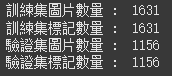

In [7]:
!ls

2_predict-JCK.ipynb
2_train-JCK.ipynb
AI_CUP_2025_aortic_valve_object_detection_predict.ipynb
AI_CUP_2025_aortic_valve_object_detection_train.ipynb
datasets
predict_txt
runs
training_image
training_label
yolo-data_aortic_valve_colab.yaml
yolo11n.pt
yolo12n.pt
yolo12x.pt
yolo_hp_cfg-Seg.yaml
yolo_hp_cfg.yaml


In [24]:
print('訓練集圖片數量 : ',len(os.listdir("./datasets/train/images")))
print('訓練集標記數量 : ',len(os.listdir("./datasets/train/labels")))
print('驗證集圖片數量 : ',len(os.listdir("./datasets/val/images")))
print('驗證集標記數量 : ',len(os.listdir("./datasets/val/labels")))

訓練集圖片數量 :  2168
訓練集標記數量 :  2168
驗證集圖片數量 :  619
驗證集標記數量 :  619


In [25]:
print(2168 + 11009)
print(619 + 3067)

13177
3686


In [ ]:
#補空txt後
訓練集圖片數量 :  13177
訓練集標記數量 :  13177
驗證集圖片數量 :  3686
驗證集標記數量 :  3686

In [9]:
#沒有補空txt前
訓練集圖片數量 :  2168
訓練集標記數量 :  2168
驗證集圖片數量 :  619
驗證集標記數量 :  619

## 這裡做一些可視化樣本

## 補充沒有標記檔txt的圖都補上空的txt，不然yolo不會納入訓練！

#### 3. 訓練模型(運行時間約15分鐘)

執行後依序有Epoch在跑代表成功

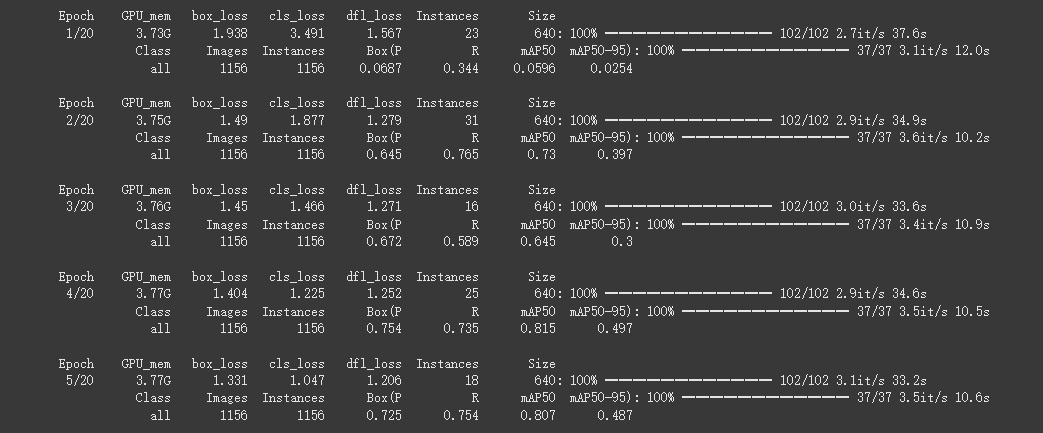

### 預測筆記
- 有些會有兩個重複框256 257 258 images2/patient0076_0256.png : 640x640 2 aortic_valves, 26.5ms
- 可能是剛好介於 大小框變化的邊界幾張，前是大後是小，但這應該是標注品質不佳導致！！
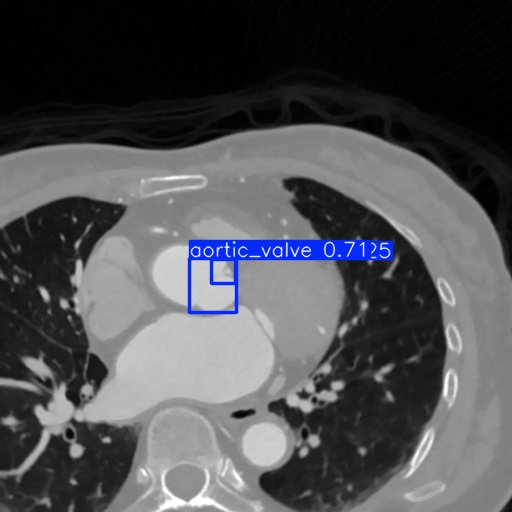

- IoU 0.5
 - box不用太準，但有無物件要準，避免FP
 - 小模型+K-flod 或是 大模型 遷移學習凍結前半段網路加速訓練！！

- 一張圖僅有無或僅有一個標注匡
 - 第二個標注匡會變成FP會將低map面積
 

 

 - YOLO-seg
 
https://github.com/vscv/Note-n-note/blob/main/YOLO.md

## 訓練筆記 ---> 2訓練筆記20251007.numbers
- 2025-10-01

- 如果您的所有影像都是 512×512，並且您的目標物體（要識別的對象）在這個尺寸下已經足夠清晰可辨，強烈建議您在訓練時將 imgsz 設為 512：
- 總之，尺寸盡量貼近原圖，是深度學習模型訓練的最佳實踐。

#### 640x64

- `12n` epoch 20  , 1:40min/ep            : train mAP50=0.789  , Publiclb=0.9042, train6 , ??
- `12n` epoch 100 , 1:40min/ep            : train mAP50=0.8797   , Publiclb=0.9236 , train10 ,  AET_(All Empty Txt)
- `v12s`epoch 10  , 2.5min/ep
- `v12m`          , 4.5min/ep
- `v12l`          , min/ep
- `12x` epoch 100 , 9min/ep ~ 15hrs     : train mAP50=0.883  , Publiclb=0.9454, train7 , AET_(All Empty Txt)
- 使用少txt分數降低
- `12x` epoch 100, 1.32min/ep ~ 2.2hrs : train mAP50=0.9119 , Publiclb=0.9358, train8, NET_(no empty txt)

- 補空txt有效提升 public lb 約 0.01
- 已證實取first 1, or best conf都會低且分數一樣！

- runs/detect/train7/weights/best.pt
    - `12x` train7-epoch100+100 接續測試: train mAP50=0.9067, Publiclb=0.9451  train9, AET_(All Empty Txt)
    - 多訓練100e反而下降了一咪咪 0.0003!!


## 訓練筆記 2 - 概念測試
- 使用小模型快速測試 -2025-10-07
 - v12s , train10
 - k-Fold
 - 640 or 512誰比較好
 - 如何聚合結果？m+l+x調配 + K-fold + 加權esamble 

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo12n.pt') #初次訓練使用YOLO官方的預訓練模型，如要使用自己的模型訓練可以將'yolo12n.pt'替換掉

# model = YOLO('yolo12x.pt')

# 從12x ep100接續訓練時
# model = YOLO('runs/detect/train7/weights/best.pt')

# model = YOLO('yolo12s.pt')
results = model.train(data="./yolo-data_aortic_valve_colab.yaml", 
          cfg="./yolo_hp_cfg.yaml",
           amp=True,
            epochs=100, #跑幾個epoch
            batch=16, #batch_size
            imgsz=640, #圖片大小640*640
            #device=0 #使用GPU進行訓練
            )

訓練完左方檔案會有run資料夾，此份Colab主要目標是得到best.pt用於下一份Colab進行預測image.png

(!!如果有重複訓練**請下載最後成功**的train編號資料夾)

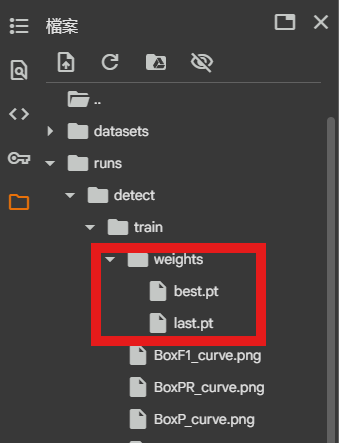

#### 4. 壓縮並下載訓練完的模型

確認下方進度條消失才有下載成功 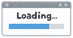

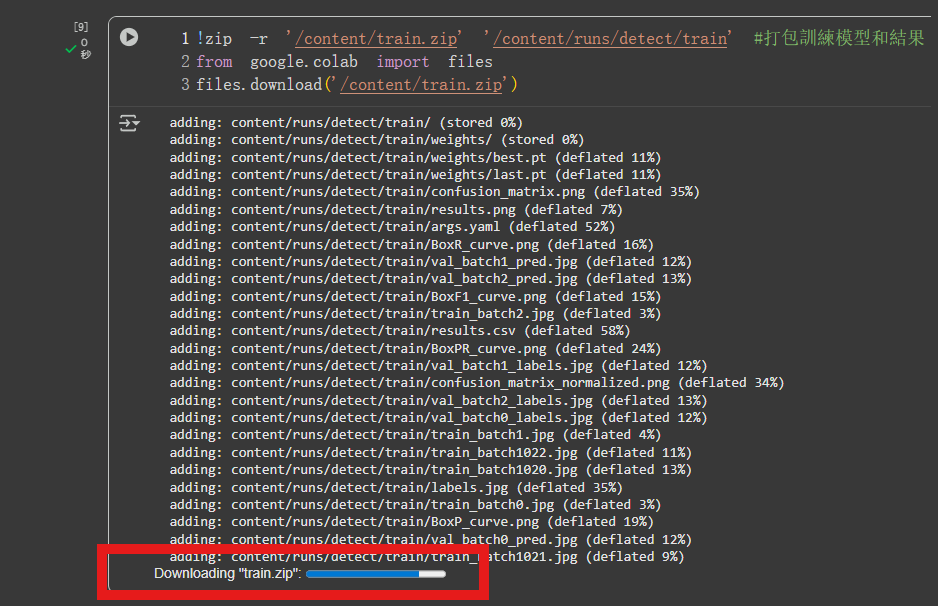

In [ ]:
!zip -r '/content/train.zip' '/content/runs/detect/train' #打包訓練模型和結果
from google.colab import files
files.download('/content/train.zip')

  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/weights/ (stored 0%)
  adding: content/runs/detect/train/weights/best.pt (deflated 11%)
  adding: content/runs/detect/train/weights/last.pt (deflated 11%)
  adding: content/runs/detect/train/confusion_matrix.png (deflated 35%)
  adding: content/runs/detect/train/results.png (deflated 7%)
  adding: content/runs/detect/train/args.yaml (deflated 52%)
  adding: content/runs/detect/train/BoxR_curve.png (deflated 16%)
  adding: content/runs/detect/train/val_batch1_pred.jpg (deflated 12%)
  adding: content/runs/detect/train/val_batch2_pred.jpg (deflated 13%)
  adding: content/runs/detect/train/BoxF1_curve.png (deflated 15%)
  adding: content/runs/detect/train/train_batch2.jpg (deflated 3%)
  adding: content/runs/detect/train/results.csv (deflated 58%)
  adding: content/runs/detect/train/BoxPR_curve.png (deflated 24%)
  adding: content/runs/detect/train/val_batch1_labels.jpg (deflated 12%)
  adding: content/ru

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

也可以右鍵直接下載best.pt和last.pt image.png

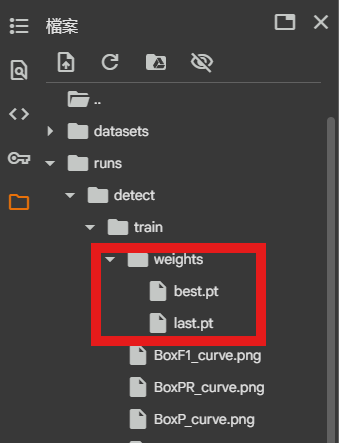